In [142]:
from keybert import KeyBERT
import pandas as pd
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
import os
from dotenv import load_dotenv
from openai import OpenAI
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import expon

In [14]:
tqdm.pandas()

# Reading Data

In [30]:
train_df

,translated_message,label,keywords
0,"""hp?"". ""first bash"". haha. ""Me too"". ""alright ...",0,"[alright, joked, push, bash, hp]"
1,"""What the fuck"". ""what 2 suicides"". ""he left""....",0,"[left, fuck, read, gg, suicides]"
2,"xd. ""easy mid"". report lion carry. ""easy oof""....",1,"[peruvians, know, carries, agg, luna]"
3,gg,0,[]
4,"Well played.. ""Well played""",0,[]
...,...,...,...
245,"""report invoker"". ""Feeding with the courier"". ...",1,"[like, dumbasses, feeding, courier, mid]"
246,Gg. 0-20. gg,0,[]
247,"""the moment the guy fell"". ""damn booster"". ""de...",0,"[damn, op, fell, demon, booster]"
248,"""Who are you talking to?"". ""ha?"" translates to...",0,"[hahaha, stupid, stuuuuupid, gg, dota3]"


In [6]:
train_df = pd.read_csv('../data/initial_datasets/dota2/dota2_grouped_train.csv')

In [12]:
train_df.drop(columns=['match', 'player'], inplace=True)

In [8]:
first = train_df['translated_message'].iloc[0]

In [11]:
first

'"hp?". "first bash". haha. "Me too". "alright guys". "Joked and that\'s enough". "maybe you will push?". "Yeah, fuck, they don\'t want to play". "I\'m not defending". "ruined it solo?". =)'

In [9]:
kw_model = KeyBERT()

temp = kw_model.extract_keywords(first, keyphrase_ngram_range=(1,1), stop_words='english', use_maxsum=True, nr_candidates=20, top_n=5)

README.md: 0.00B [00:00, ?B/s]

In [26]:
train_df['keywords'] = train_df['translated_message'].progress_apply(
    lambda text: [
        kw[0] for kw in kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 1),
            stop_words='english',
            use_maxsum=True,
            
        )
    ][:5]
)

  0%|          | 0/250 [00:00<?, ?it/s]

In [32]:
class_docs = train_df.groupby('label')['keywords'].apply(lambda x: ' '.join([' '.join(kws) for kws in x])).reset_index(name='pseudo_doc')

vectorizer = TfidfVectorizer()
vectors = vectorizer.fit_transform(class_docs['pseudo_doc'])
features_names = vectorizer.get_feature_names_out()

ctfidf_df = pd.DataFrame(vectors.toarray(), columns=features_names, index=class_docs['label'])

print(ctfidf_df)

             10       100        13        25        26      2800      2975  \
label                                                                         
0      0.000000  0.033012  0.000000  0.033012  0.033012  0.033012  0.000000   
1      0.098888  0.000000  0.098888  0.000000  0.000000  0.000000  0.098888   

            2hp        2k        3k  ...        wp        xd      xddd  \
label                                ...                                 
0      0.033012  0.000000  0.023488  ...  0.000000  0.066023  0.033012   
1      0.000000  0.098888  0.070359  ...  0.098888  0.000000  0.000000   

            yay       yes      yuri      zeus       zzz  серьезно     удача  
label                                                                        
0      0.033012  0.099035  0.000000  0.033012  0.033012  0.033012  0.033012  
1      0.000000  0.000000  0.098888  0.000000  0.000000  0.000000  0.000000  

[2 rows x 390 columns]


In [33]:
# Concatenate all texts within each 'final_b' category
grp_df = pd.DataFrame([])
grp_df = train_df.copy()
grp_df['grouped_texts'] = train_df.groupby('label')['translated_message'].transform(lambda x: ' '.join(x))

# Remove duplicate rows to keep unique pseudo-documents per category
unique_docs = grp_df[['grouped_texts', 'label']].drop_duplicates()
display(unique_docs)

# Step 1: Extract Distinct Keywords using C-TF-IDF
vectorizer = TfidfVectorizer()
vectors = vectorizer.fit_transform(unique_docs['grouped_texts'])
feature_names = vectorizer.get_feature_names_out()

,grouped_texts,label
0,"""hp?"". ""first bash"". haha. ""Me too"". ""alright ...",0
2,"xd. ""easy mid"". report lion carry. ""easy oof""....",1


In [34]:
# Function to highlight top N distinct terms per category based on C-TF-IDF scores
def highlight_top_n_terms(ctfidf_matrix, top_n=20):
    top_terms = {}
    for index, row in ctfidf_matrix.iterrows():
        top_indices = row.argsort()[-top_n:][::-1]
        top_terms[index] = [(ctfidf_matrix.columns[i], row[i]) for i in top_indices]
    return top_terms

# Extract top N distinct terms per category
top_distinct_terms = highlight_top_n_terms(ctfidf_df, top_n=20)

for category, terms in top_distinct_terms.items():
    print(f"Category: {category}")
    for term, score in terms:
        print(f"  {term}: {score:.4f}")
    print("\n")

Category: 0
  gg: 0.3993
  lol: 0.2584
  report: 0.2311
  hahaha: 0.2114
  play: 0.1651
  message: 0.1651
  haha: 0.1644
  fuck: 0.1409
  bad: 0.1320
  game: 0.1320
  stupid: 0.1174
  techies: 0.0990
  left: 0.0990
  pudge: 0.0990
  let: 0.0990
  blood: 0.0990
  yes: 0.0990
  english: 0.0990
  pause: 0.0990
  thank: 0.0705


Category: 1
  say: 0.1978
  sorry: 0.1978
  dumbasses: 0.1978
  russian: 0.1978
  hahaha: 0.1407
  mid: 0.1407
  lol: 0.1407
  like: 0.1407
  haha: 0.1407
  chaos: 0.0989
  courier: 0.0989
  pangolier: 0.0989
  slark: 0.0989
  peruvians: 0.0989
  pity: 0.0989
  pubg: 0.0989
  quadrilane: 0.0989
  sky: 0.0989
  quieres: 0.0989
  retarded: 0.0989




In [35]:
import pandas as pd
from keybert import KeyBERT

# Assuming data_df is your DataFrame containing 'text' and 'final_b' columns

# Initialize KeyBERT for keyword extraction
kw_model = KeyBERT()

def extract_keywords(documents):
    """
    Function to extract distinct keywords from a list of documents.
    Adjust parameters as necessary for your specific requirements.
    """
    # Combine documents into a single string for KeyBERT analysis
    combined_documents = " ".join(documents)
    keywords = kw_model.extract_keywords(combined_documents, keyphrase_ngram_range=(1, 1), stop_words='english', top_n=20)

    # Return only distinct keywords, discarding scores
    return list(set([kw[0] for kw in keywords]))

# Group the dataframe by 'final_b' and extract distinct keywords for each group
final_b_keywords = {}
for final_b, group in train_df.groupby('label'):
    documents = group['translated_message'].tolist()
    final_b_keywords[final_b] = extract_keywords(documents)

# Print or return the keywords associated with each 'final_b' group
print(final_b_keywords)


{0: ['hp', 'mage', 'defending', 'play', 'jungle', 'solo', 'ggwp', 'game', 'offlane', 'duel', 'kraken', 'rampage', 'kill', 'doom', 'gg', 'playing', 'ogre', 'hate', 'games', 'jugg'], 1: ['lion', 'jungle', 'pangolier', 'mid', 'enemy', 'oof', 'dota', 'midlaner', 'lc', 'carry', 'necro', 'shadow', 'midas', 'ult', 'peru', 'peruvian', 'luna', 'peruvians', 'sven', 'xd']}


In [36]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer


class CTFIDFVectorizer(TfidfTransformer):
  def __init__(self, *args, **kwargs):
    super(CTFIDFVectorizer, self).__init__(*args, **kwargs)

  def fit(self, X: sp.csr_matrix, n_samples: int):
    """Learn the idf vector (global term weights) """
    _, n_features = X.shape
    df = np.squeeze(np.asarray(X.sum(axis=0)))
    idf = np.log(n_samples / df)
    self._idf_diag = sp.diags(idf, offsets=0,
                              shape=(n_features, n_features),
                              format='csr',
                              dtype=np.float64)
    return self

  def transform(self, X: sp.csr_matrix) -> sp.csr_matrix:
    """Transform a count-based matrix to c-TF-IDF """
    X = X * self._idf_diag
    X = normalize(X, axis=1, norm='l1', copy=False)
    return X

In [51]:
train_df.rename(columns={'translated_message': 'text'}, inplace=True)

In [52]:
lbl2idx = {'toxic': 1, 'non-toxic': 0}
idx2lbl = {lbl:n for n, lbl in lbl2idx.items()}
print(idx2lbl)

def numLabel(row):
  tox_lbl = row['label']
  return tox_lbl

train_df['prosocial_num'] = train_df.apply(lambda row: numLabel(row), axis=1)
print("1")
# Create documents per label
docs = train_df[['text',"prosocial_num"]] #pd.DataFrame({'Document': newsgroups.data, 'Class': newsgroups.target})
docs_per_class = docs.groupby(['prosocial_num'], as_index=False).agg({'text': ' '.join})
print("2")
# Create c-TF-IDF
count = CountVectorizer().fit_transform(docs_per_class.text)
ctfidf = CTFIDFVectorizer().fit_transform(count, n_samples=len(docs))

# Create bag of words
count_vectorizer = CountVectorizer(stop_words='english').fit(docs_per_class.text)
count = count_vectorizer.transform(docs_per_class.text)
words = count_vectorizer.get_feature_names_out()

# Extract top 10 words per class
ctfidf = CTFIDFVectorizer().fit_transform(count, n_samples=len(docs)).toarray()

words_per_class = {idx2lbl[label]: [words[index] for index in ctfidf[label].argsort()[-15:]]
                   for c, label in enumerate(docs_per_class.prosocial_num)}

for c, list_words in words_per_class.items():
    print(f"---{c.upper()}--- \n\t{list_words}")
    print(docs_per_class[docs_per_class['prosocial_num'] == lbl2idx[c]]['text'].tolist()[0])

print(docs_per_class[0:10])

{1: 'toxic', 0: 'non-toxic'}
1
2
---NON-TOXIC--- 
	['yeah', 'played', 'good', 'kill', 'xd', 'mid', 'don', 'fuck', 'hahaha', 'haha', 'easy', 'game', 'report', 'lol', 'gg']
"hp?". "first bash". haha. "Me too". "alright guys". "Joked and that's enough". "maybe you will push?". "Yeah, fuck, they don't want to play". "I'm not defending". "ruined it solo?". =) "What the fuck". "what 2 suicides". "he left". read chat. gg. gg gg Well played.. "Well played" end. "please". the kraken has been unleashed. gg "come on". "rampage incoming" gg. "classic Anti-Mage game..." "How many are in your party?". "what 2800". "how you fucking annoy with your dis". "the whole game". "I was getting fucked up" "what bye?". FACELESS VOID. why hate me :(. "why hate me". :(. snipshit. ok "Don't be racist with an Archon, dogs.". "damn I feel small". oleee. ??. magnus gg sniper revenge time?. "abandoning if that's fine guys?". w. t. f. I pick Techies.. I think I'm good.. x. X. XD. whattattatatattata. yeah. ouch. Fuck. 

In [87]:
pro_social_def = "An interaction or behavior that is intended to result in a benefit to another player. \
This includes, but is not limited, to behaviors such as helping and defending, assisting or acting in \
someone else’s interest, volunteering, donating, and comforting. As well as cooperation and sharing, \
expressing empathy and emotionalawareness"

unclear_def = "Neutral communication, not enough context to judge if it is prosocil (i.e., can be interpreted either way), of a mix of prosocial and toxic (e.g., could be sarcasm)."

non_toxic_def = "An interaction or behavior that is intended to benefit another player. This includes, but is not limited to, helping, defending, " \
               "assisting, volunteering, donating, comforting, cooperating, sharing, or expressing empathy and emotional awareness. It also includes " \
               "neutral communication where there may not be enough context to determine whether the behavior is prosocial — for example, if the message " \
               "could be interpreted as either prosocial or toxic (such as in cases of sarcasm or mixed signals)."
toxic_def = "Explicitly / Implicitly toxic with an intent of offending others"

prosoc_kwds = ["stay", "play", "gg", "invite", "revive", "need", "pls", "thx", "bro", "near", "haha", "sorry",
               "ty", "respawn", "come", "ping", "help", "go", "ok", "please", "thank", "lol"] + \
                ['follow', 'near', 'ty', 'wait', 'thanks', 'need', 'im', 'stay', 'come', 'guys', 'bro', 'ok', 'gg', 'pls', 'help']

unclear_kwds = ["guys", "join", "yes", "ok", "party", "lol", "play", "gg", "guy", "team", "lol", "come", "go"] + \
                ['ur', 'bot', 'la', 'come', 'land', 'just', 'join', 'got', 'sniper', 'ok', 'im', 'play', 'lol', 'party', 'gg']

non_toxic_kwds = prosoc_kwds + unclear_kwds

toxic_kwds = ["team", "gay", "camping", "xd", "ass", "trash", "team", "lol", "noob", "ez", "lol", "stfu", "bot",
              'lmao', 'haha'] + ['dont', 'play', 'lmao', 'gay', 'like', 'camping', 'bad', 'ass', 'xd', 'trash',
                                 'team', 'ur', 'lol', 'noob', 'ez']

#typos due to typing fast during the game, fustrated repeats when banging on the same key
prompt = f"Simulate [LEN] realistic game text chat exchanges (using abbreviations, typos due to typing fast during the game\
, COD slang, fustrated repeats when banging on the same key, etc.) \
between player A and Player B in COD text game chat. Communication from Player A is characterized as [DEF]\
This player is also likely to use keywords such as [KWDS] in their communication. \
Player B is neutral. Each message is on average [WRD_LEN] words long. Format as [P1] msg1 \n [P2] msg2 \n ..."

#Concatenate all the messages from player A as one string and separate each message by . \
#Make only [LEN] exhanges."

In [66]:
prompt = f"{prompt.replace('[DEF]', non_toxic_def).replace('[KWDS]', ', '.join(random.sample(prosoc_kwds,3))).replace('[LEN]', str(12)).replace('[WRD_LEN]', str(2))}"

In [67]:
load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=API_KEY)

In [68]:
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

In [71]:
print(response.choices[0].message.content)

Sure, here are 12 simulated game chat exchanges:

1.  
[P1] Need help!  
[P2] omw  

2.  
[P1] Nice shot!  
[P2] thx  

3.  
[P1] Cover me!  
[P2] got u  

4.  
[P1] Need ammo  
[P2] here!  

5.  
[P1] Thx bro  
[P2] np  

6.  
[P1] Flank left  
[P2] ok  

7.  
[P1] Go in!  
[P2] rdy  

8.  
[P1] Sorry!  
[P2] it's ok  

9.  
[P1] Good job!  
[P2] ty  

10.  
[P1] Spot enemy  
[P2] where?  

11.  
[P1] Revive pls  
[P2] coming!  

12.  
[P1] Push now  
[P2] yep  


In [120]:
orig_train_df = pd.read_csv('../data/initial_datasets/dota2/dota2_grouped_train.csv')

In [126]:
temp

match                                                                33
player                                                                1
translated_message    "hp?". "first bash". haha. "Me too". "alright ...
label                                                                 0
Name: 0, dtype: object

In [127]:
temp = orig_train_df.iloc[0]
temp.str.split(".")

match                                                               NaN
player                                                              NaN
translated_message    ["hp?",  "first bash",  haha,  "Me too",  "alr...
label                                                               NaN
Name: 0, dtype: object

In [129]:
orig_train_df['words_split'] = orig_train_df['translated_message'].str.split(".")

In [132]:
orig_train_df['num_words'] = orig_train_df['words_split'].apply(len)

In [134]:
orig_train_df['num_words'].mean()

np.float64(6.328)

(array([195.,  43.,   7.,   3.,   1.,   0.,   0.,   1.]),
 array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.]),
 <BarContainer object of 8 artists>)

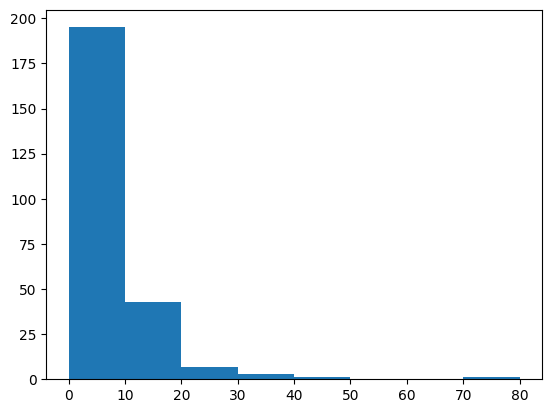

In [141]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
plt.hist(orig_train_df['num_words'], bins=bins)

In [143]:
loc, scale = expon.fit(orig_train_df['num_words'])

In [156]:
sample = np.random.exponential(scale) + loc
print(np.round(sample))

4.0


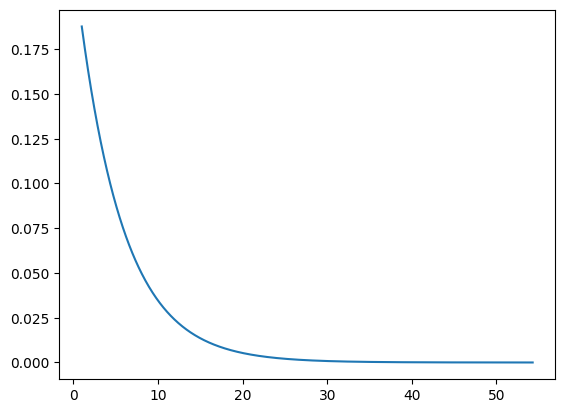

In [144]:
x = np.linspace(loc, loc+10 * scale, 1000)
pdf = expon.pdf(x, loc=loc, scale=scale)

plt.plot(x, pdf)

In [135]:
orig_train_df['num_words'].std()

np.float64(8.208405917767674)

In [73]:
prompt = f"Simulate [LEN] realistic game text chat exchanges (using abbreviations, typos due to typing fast during the game\
, COD slang, fustrated repeats when banging on the same key, etc.) \
between player A and Player B in COD text game chat. Communication from Player A is characterized as [DEF]\
This player is also likely to use keywords such as [KWDS] in their communication. \
Player B is neutral. Each message is on average [WRD_LEN] words long. Format as [P1] msg1 \n [P2] msg2 \n ..."

prompt = f"{prompt.replace('[DEF]', toxic_def).replace('[KWDS]', ', '.join(random.sample(toxic_kwds,3))).replace('[LEN]', str(12)).replace('[WRD_LEN]', str(2))}"

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

print(response.choices[0].message.content)

[P1] U all suck! 
[P2] Chill dude 
[P1] lol noobs 
[P2] We trying 
[P1] Git gud 
[P2] Working on it

[P1] stfu loser 
[P2] Real mature 
[P1] 1v1 me 
[P2] Busy now 
[P1] Excuses! 
[P2] Sure, buddy

[P1] u camping? 
[P2] Just tactics 
[P1] lmao coward 
[P2] If u say 
[P1] Get shamed 
[P2] Alrighty

[P1] ur trash 
[P2] Nice one 
[P1] ez clap 
[P2] gg man 
[P1] git rekt 
[P2] Haha alright

[P1] Stop hiding 
[P2] It's strategy 
[P1] lmfao trash 
[P2] If u think 
[P1] stfu camper 
[P2] Whatever dude

[P1] That aim lol 
[P2] Still learning 
[P1] Git gud scrub 
[P2] I'll try 
[P1] U hopeless 
[P2] Maybe

[P1] omfg n00b 
[P2] Okay then 
[P1] git gud pls 
[P2] Working on it 
[P1] Laughing hard 
[P2] Good for u

[P1] no skills! 
[P2] Your opinion 
[P1] stfu kid 
[P2] As u wish 
[P1] No chance 
[P2] Okay

[P1] stop feeding 
[P2] Trying hard 
[P1] lol ur bad 
[P2] Just playing 
[P1] As if 
[P2] True words

[P1] ez game 
[P2] Good match 
[P1] ur awful 
[P2] Thanks bro 
[P1] not even close 
[P2] Inde

In [74]:
print(response.choices[0].message.content)

[P1] U all suck! 
[P2] Chill dude 
[P1] lol noobs 
[P2] We trying 
[P1] Git gud 
[P2] Working on it

[P1] stfu loser 
[P2] Real mature 
[P1] 1v1 me 
[P2] Busy now 
[P1] Excuses! 
[P2] Sure, buddy

[P1] u camping? 
[P2] Just tactics 
[P1] lmao coward 
[P2] If u say 
[P1] Get shamed 
[P2] Alrighty

[P1] ur trash 
[P2] Nice one 
[P1] ez clap 
[P2] gg man 
[P1] git rekt 
[P2] Haha alright

[P1] Stop hiding 
[P2] It's strategy 
[P1] lmfao trash 
[P2] If u think 
[P1] stfu camper 
[P2] Whatever dude

[P1] That aim lol 
[P2] Still learning 
[P1] Git gud scrub 
[P2] I'll try 
[P1] U hopeless 
[P2] Maybe

[P1] omfg n00b 
[P2] Okay then 
[P1] git gud pls 
[P2] Working on it 
[P1] Laughing hard 
[P2] Good for u

[P1] no skills! 
[P2] Your opinion 
[P1] stfu kid 
[P2] As u wish 
[P1] No chance 
[P2] Okay

[P1] stop feeding 
[P2] Trying hard 
[P1] lol ur bad 
[P2] Just playing 
[P1] As if 
[P2] True words

[P1] ez game 
[P2] Good match 
[P1] ur awful 
[P2] Thanks bro 
[P1] not even close 
[P2] Inde

In [75]:
resp = response.choices[0].message.content

In [76]:
resp

"[P1] U all suck! \n[P2] Chill dude \n[P1] lol noobs \n[P2] We trying \n[P1] Git gud \n[P2] Working on it\n\n[P1] stfu loser \n[P2] Real mature \n[P1] 1v1 me \n[P2] Busy now \n[P1] Excuses! \n[P2] Sure, buddy\n\n[P1] u camping? \n[P2] Just tactics \n[P1] lmao coward \n[P2] If u say \n[P1] Get shamed \n[P2] Alrighty\n\n[P1] ur trash \n[P2] Nice one \n[P1] ez clap \n[P2] gg man \n[P1] git rekt \n[P2] Haha alright\n\n[P1] Stop hiding \n[P2] It's strategy \n[P1] lmfao trash \n[P2] If u think \n[P1] stfu camper \n[P2] Whatever dude\n\n[P1] That aim lol \n[P2] Still learning \n[P1] Git gud scrub \n[P2] I'll try \n[P1] U hopeless \n[P2] Maybe\n\n[P1] omfg n00b \n[P2] Okay then \n[P1] git gud pls \n[P2] Working on it \n[P1] Laughing hard \n[P2] Good for u\n\n[P1] no skills! \n[P2] Your opinion \n[P1] stfu kid \n[P2] As u wish \n[P1] No chance \n[P2] Okay\n\n[P1] stop feeding \n[P2] Trying hard \n[P1] lol ur bad \n[P2] Just playing \n[P1] As if \n[P2] True words\n\n[P1] ez game \n[P2] Good matc

In [83]:
p1_lines = []
p2_lines = []

for line in resp.splitlines():
    line = line.strip()
    if line.startswith("[P1]"):
        p1_lines.append(f"\"{line[5:]}\"")
    elif line.startswith("[P2]"):
        p2_lines.append(f"\"{line[5:]}\"")

In [84]:
p1_lines

['"U all suck!"',
 '"lol noobs"',
 '"Git gud"',
 '"stfu loser"',
 '"1v1 me"',
 '"Excuses!"',
 '"u camping?"',
 '"lmao coward"',
 '"Get shamed"',
 '"ur trash"',
 '"ez clap"',
 '"git rekt"',
 '"Stop hiding"',
 '"lmfao trash"',
 '"stfu camper"',
 '"That aim lol"',
 '"Git gud scrub"',
 '"U hopeless"',
 '"omfg n00b"',
 '"git gud pls"',
 '"Laughing hard"',
 '"no skills!"',
 '"stfu kid"',
 '"No chance"',
 '"stop feeding"',
 '"lol ur bad"',
 '"As if"',
 '"ez game"',
 '"ur awful"',
 '"not even close"',
 '"cry more"',
 '"suuuure lmao"',
 '"u mad bro?"',
 '"trash aim"',
 '"smh noob"',
 '"like zero"']

In [85]:
'. '.join(p1_lines)

'"U all suck!". "lol noobs". "Git gud". "stfu loser". "1v1 me". "Excuses!". "u camping?". "lmao coward". "Get shamed". "ur trash". "ez clap". "git rekt". "Stop hiding". "lmfao trash". "stfu camper". "That aim lol". "Git gud scrub". "U hopeless". "omfg n00b". "git gud pls". "Laughing hard". "no skills!". "stfu kid". "No chance". "stop feeding". "lol ur bad". "As if". "ez game". "ur awful". "not even close". "cry more". "suuuure lmao". "u mad bro?". "trash aim". "smh noob". "like zero"'

In [86]:
p2_lines

['"Chill dude"',
 '"We trying"',
 '"Working on it"',
 '"Real mature"',
 '"Busy now"',
 '"Sure, buddy"',
 '"Just tactics"',
 '"If u say"',
 '"Alrighty"',
 '"Nice one"',
 '"gg man"',
 '"Haha alright"',
 '"It\'s strategy"',
 '"If u think"',
 '"Whatever dude"',
 '"Still learning"',
 '"I\'ll try"',
 '"Maybe"',
 '"Okay then"',
 '"Working on it"',
 '"Good for u"',
 '"Your opinion"',
 '"As u wish"',
 '"Okay"',
 '"Trying hard"',
 '"Just playing"',
 '"True words"',
 '"Good match"',
 '"Thanks bro"',
 '"Indeed"',
 '"It\'s fine"',
 '"I know"',
 '"Not really"',
 '"Still learning"',
 '"We all start"',
 '"Aiming higher"']

In [157]:
loc, scale = expon.fit(orig_train_df['num_words'])

In [165]:
data = {
    'translated_messages': [],
    'label': []
}
for i in tqdm(range(2)):

    prompt = f"Simulate [LEN] realistic game text chat exchanges (using abbreviations, typos due to typing fast during the game\
    , COD slang, fustrated repeats when banging on the same key, etc.) \
    between player A and Player B in COD text game chat. Communication from Player A is characterized as [DEFA]\
    This player is also likely to use keywords such as [KWDSA] in their communication. \
    Player B is characterized as [DEFB]. They are likely to use keywords such as [KWDSB]. \
    Each message is on average [WRD_LEN] words long. Format as [P1] msg1 \n [P2] msg2 \n ..."

    num_words = int(np.random.exponential(scale) + loc)

    defa = random.randint(0, 1)
    defb = random.randint(0, 1)
    if defa == 0:
        definitiona = toxic_def
        kwdsa = toxic_kwds
    else:
        definitiona = non_toxic_def
        kwdsa = non_toxic_kwds
    
    if defb == 0:
        definitionb = toxic_def
        kwdsb = toxic_kwds
    else:
        definitiob = non_toxic_def
        kwdsb = non_toxic_kwds

    prompt = f"{prompt.replace('[DEFA]', definitiona).replace('[KWDSA]', ', '.join(random.sample(kwdsa,3))).replace('[DEFB]', definitionb).replace('[KWDSB]', ', '.join(random.sample(kwdsb, 3))).replace('[LEN]', str(num_words)).replace('[WRD_LEN]', str(2))}"

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    resp = response.choices[0].message.content

    p1_lines = []
    p2_lines = []

    for line in resp.splitlines():
        line = line.strip()
        if line.startswith("[P1]"):
            p1_lines.append(f"\"{line[5:]}\"")
        elif line.startswith("[P2]"):
            p2_lines.append(f"\"{line[5:]}\"")


    data['translated_messages'].append('. '.join(p1_lines))
    data['label'].append(defa)

    data['translated_messages'].append('. '.join(p2_lines))
    data['label'].append(defb)



100%|██████████| 2/2 [00:10<00:00,  5.06s/it]


In [166]:
new_df = pd.DataFrame(data)

In [167]:
new_df

,translated_messages,label
0,"""gg, nice!"". ""need bkup?"". ""thx, man"". ""you ok...",1
1,"""pathetic, bro"". ""nO way, scrub"". ""whatever"". ...",1
2,"""gj bro"". ""need backup?"". ""let's land"". ""cover...",1
3,"""u bad"". ""nah u trash"". ""noob spot"". ""like u c...",0


In [162]:
gen_df = pd.DataFrame(data)

In [ ]:
gen_df = gen_df[gen_df['translated_messages'].str.len() != 0]

,translated_messages,label
0,"""on ur 6"". ""thx for cover"". ""lol gg"". ""ammo he...",1
1,"""noob camper"". ""ur slow"". ""game sux"". ""like I ...",0
2,"""follow me"". ""ok np"". ""u ok?"". ""we good"". ""hel...",1
3,"""noob move"". ""trash team"". ""ez win"". ""1v1 ez""....",0
4,"""dont camp!"". ""omg stfu"". ""trash team"". ""noob ...",0
...,...,...
243,"""haha noob"". ""camping pro"". ""gg trash"". ""haha ...",0
246,"""gg man"". ""need help?"". ""cover me"". ""let's win...",1
247,"""u suck"". ""noob, stay back"". ""why u"". ""die alr...",1
248,"""Need help?"". ""Ok np"". ""Near obj!"". ""Move plz""...",1


In [ ]:
gen_df = pd.concat([gen_df, new_df.sample(n=4)])

In [168]:
gen_df

,translated_messages,label
0,"""on ur 6"". ""thx for cover"". ""lol gg"". ""ammo he...",1
1,"""noob camper"". ""ur slow"". ""game sux"". ""like I ...",0
2,"""follow me"". ""ok np"". ""u ok?"". ""we good"". ""hel...",1
3,"""noob move"". ""trash team"". ""ez win"". ""1v1 ez""....",0
4,"""dont camp!"". ""omg stfu"". ""trash team"". ""noob ...",0
...,...,...
245,,0
246,"""gg man"". ""need help?"". ""cover me"". ""let's win...",1
247,"""u suck"". ""noob, stay back"". ""why u"". ""die alr...",1
248,"""Need help?"". ""Ok np"". ""Near obj!"". ""Move plz""...",1


In [115]:
gen_df = gen_df[gen_df['translated_messages'].str.len() != 0]

In [169]:
gen_df.to_csv('../data/generated/dota2/conversational_generations/grouped_conversational_var_len.csv', index=False)